In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# Move to project root
os.chdir("/home/ryu/code/DL_project")

print("CWD:", os.getcwd())
print("Files:", os.listdir("."))


2026-01-28 19:46:24.172249: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 19:46:24.179524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-28 19:46:24.725602: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 19:46:27.888155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

CWD: /home/ryu/code/DL_project
Files: ['.gitignore', 'outputs', '.git', 'VENV', '.venv', 'requirements.txt', 'models', 'src', 'datasets', 'notebooks']


In [2]:
CNN_MODEL_PATH = "models/cnn_v1.h5"
assert os.path.exists(CNN_MODEL_PATH), "CNN model file not found"

cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)
cnn_model.summary()


2026-01-28 19:46:34.809596: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,478 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [3]:
dummy_input = tf.zeros((1, 224, 224, 3))
_ = cnn_model(dummy_input)

# Optional: suppress metrics warning
dummy_pred = cnn_model.predict(dummy_input, verbose=0)
num_classes = dummy_pred.shape[-1]
dummy_y = tf.one_hot(tf.zeros((1,), dtype=tf.int32), num_classes)
_ = cnn_model.evaluate(dummy_input, dummy_y, verbose=0)

print("Model input shape:", cnn_model.input_shape)
print("Model output shape:", cnn_model.output_shape)


Model input shape: (None, 224, 224, 3)
Model output shape: (None, 4)


In [4]:
last_conv_layer = None
for layer in reversed(cnn_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

assert last_conv_layer is not None, "No Conv2D layer found in CNN"

print("Last Conv layer:", last_conv_layer.name)

conv_layer_idx = cnn_model.layers.index(last_conv_layer)
print("Last conv layer index:", conv_layer_idx)


Last Conv layer: conv2d_2
Last conv layer index: 4


In [5]:
input_tensor = tf.keras.Input(shape=cnn_model.input_shape[1:])
x = input_tensor

for layer in cnn_model.layers[:conv_layer_idx + 1]:
    x = layer(x)

feature_extractor = tf.keras.models.Model(
    inputs=input_tensor,
    outputs=x
)

# Force build
_ = feature_extractor(dummy_input)

print("Feature extractor output shape:", feature_extractor.output_shape)


Feature extractor output shape: (None, 52, 52, 128)


In [6]:
classifier_input = tf.keras.Input(
    shape=feature_extractor.output_shape[1:]
)
y = classifier_input

for layer in cnn_model.layers[conv_layer_idx + 1:]:
    y = layer(y)

classifier = tf.keras.models.Model(
    inputs=classifier_input,
    outputs=y
)

# Force build
dummy_features = feature_extractor(dummy_input)
_ = classifier(dummy_features)

print("Classifier built successfully")


Classifier built successfully


In [7]:
def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array, img


In [8]:
def make_gradcam_heatmap(img_array):
    # Forward through feature extractor
    conv_outputs = feature_extractor(img_array, training=False)

    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)
        predictions = classifier(conv_outputs, training=False)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]  # scalar

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise RuntimeError("Gradients are None — check model connectivity")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.nn.relu(heatmap)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()


In [9]:
glioma_dir = "datasets/BT-MRI/test/glioma"
IMG_PATH = os.path.join(glioma_dir, os.listdir(glioma_dir)[0])

print("Using image:", IMG_PATH)
assert os.path.exists(IMG_PATH), "Image not found"


Using image: datasets/BT-MRI/test/glioma/BT-MRI Test GL (281).jpg


In [10]:
img_array, original_img_pil = preprocess_image(IMG_PATH)
heatmap = make_gradcam_heatmap(img_array)


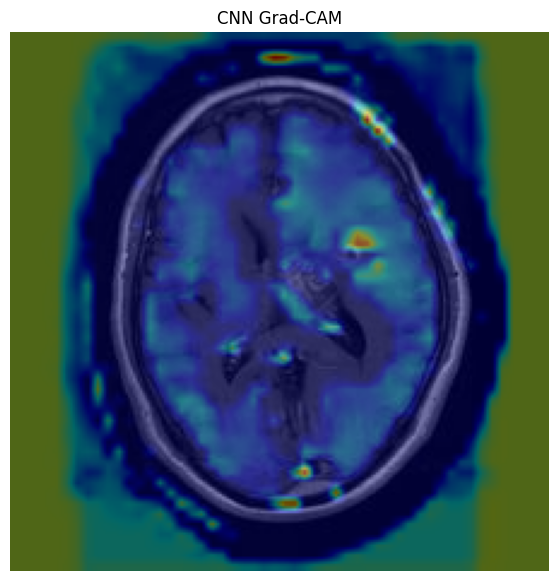

In [11]:
# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply colormap
heatmap_colored = cv2.applyColorMap(
    heatmap_uint8, cv2.COLORMAP_JET
)

# Prepare original image
original_np = np.array(original_img_pil)
original_bgr = cv2.cvtColor(original_np, cv2.COLOR_RGB2BGR)

# Overlay
superimposed = cv2.addWeighted(
    original_bgr, 0.6, heatmap_colored, 0.4, 0
)

# Save
os.makedirs("outputs/gradcam", exist_ok=True)
cv2.imwrite(
    "outputs/gradcam/cnn_gradcam_fixed.png",
    superimposed
)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title("CNN Grad-CAM")
plt.axis("off")
plt.show()


#### Multiple images

In [12]:


OUTPUT_DIR = "outputs/gradcam/cnn_grad"
os.makedirs(OUTPUT_DIR, exist_ok=True)

image_files = os.listdir(glioma_dir)[:10]   # 🔁 limit to 10 (change if needed)

for img_name in image_files:
    img_path = os.path.join(glioma_dir, img_name)

    img_array, original_img_pil = preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array)

    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_np = np.array(original_img_pil)
    original_bgr = cv2.cvtColor(original_np, cv2.COLOR_RGB2BGR)

    superimposed = cv2.addWeighted(
        original_bgr, 0.6, heatmap_color, 0.4, 0
    )

    save_path = os.path.join(
        OUTPUT_DIR, f"cnn_grad_{img_name}"
    )
    cv2.imwrite(save_path, superimposed)

    print("Saved:", save_path)


Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (281).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (191).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (84).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (71).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (129).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (223).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (14).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (66).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (107).jpg
Saved: outputs/gradcam/cnn_grad/cnn_grad_BT-MRI Test GL (183).jpg
